In [1]:
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis as PA
from modlamp.descriptors import PeptideDescriptor, GlobalDescriptor
#from sklearn.model_selection import train_test_split
import pandas as pd
import os, re, math, platform
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from numpy import linalg as la
import os
import random
import warnings
warnings.filterwarnings('ignore')
from fea_extract import read_fasta,insert_AAC
import random
seed = 10

In [5]:
def del_data(seqname):
    seqname = seqname.to_numpy()
    newseq = []
    j = seqname.shape[0]
    for i in range(j):
        if 6<=len(seqname[i][1])<=100:
            newseq.append(seqname[i])
    newseq = np.array(newseq)
    print('new shape：',newseq.shape)
    newseq = pd.DataFrame(data = newseq,columns=["Id", "Sequence"])
    return newseq

#AAC
def AAC(seq_df):
    # Compute AAC for peptide in specific A.A
    def get_aac(seq, aa):
        return seq.count(aa) / len(seq) * 100

    # processing data_frame
    data_size = seq_df.size
    for ll in _AALetter:
        seq_df['{}'.format(ll)] = list(map(get_aac, seq_df['Sequence'], [ll] * data_size))
    return seq_df
def get_aac(seq, aa):
        return seq.count(aa) / len(seq) * 100

_AALetter = ['A', 'C', 'D', 'E', 'F', 'G', 'H',
             'I', 'K', 'L', 'M', 'N', 'P', 'Q',
             'R', 'S', 'T', 'V', 'W', 'Y']

def plot_aac(seq1,seq2):
    seq1 = del_data(seq1)
    seq2 = del_data(seq2)
    seq1aac = AAC(seq1)
    seq2aac = AAC(seq2)
    feature = seq1.columns[2:]
    seq1aac = seq1aac[feature]
    seq2aac = seq2aac[feature]
    seq1AAC = seq1aac.mean()/100
    seq2AAC = seq2aac.mean()/100
    all_seq = pd.concat([seq1AAC,seq2AAC],axis=1)
    all_seq.columns = ['ACP','Non-ACP']
    all_seq.plot.bar(figsize=(15,7),fontsize=15,rot=45,grid = False,width = 0.8)
    plt.xlabel("Amino acid composition", fontsize='x-large')
    plt.ylabel("Frequency", fontsize='x-large')

def plot_aac_pie(seq1,seq2):
    seq1 = del_data(seq1)
    seq2 = del_data(seq2)
    seq1aac = AAC(seq1)
    seq2aac = AAC(seq2)
    feature = seq1.columns[2:]
    seq1aac = seq1aac[feature]
    seq2aac = seq2aac[feature]
    seq1AAC = seq1aac.mean()/100
    seq2AAC = seq2aac.mean()/100
    all_seq = pd.concat([seq1AAC,seq2AAC],axis=1)
    all_seq.columns = ['ACP','Non-ACP']
    all_seq.plot(kind='pie',autopct='%.1f%%',startangle = 180,subplots=True,wedgeprops = {'linewidth': 1.5, 'edgecolor':'green'}, 
           textprops = {'fontsize':10, 'color':'black'})
#     plt.xlabel("Amino acid composition", fontsize='x-large')
#     plt.ylabel("Frequency", fontsize='x-large')

#N AND C wise analysis
def seqN5C5(SEQ):
    encodeN5 = []
    encodeC5 = []
    seq = SEQ['Sequence']
    for fastas in seq:
        fastas_N5 = '%s' % fastas[:5]
        fastas_C5 = '%s' % fastas[-5:]
        encodeN5.append(fastas_N5)
        encodeC5.append(fastas_C5)
    encodingN5 = pd.DataFrame(encodeN5,columns=['Sequence'])
    SEQN5 = pd.concat([SEQ.iloc[:,0],encodingN5],axis=1)
    encodingC5 = pd.DataFrame(encodeC5,columns=['Sequence'])
    SEQC5 = pd.concat([SEQ.iloc[:,0],encodingC5],axis=1)
    return SEQN5,SEQC5
def plot_N5C5(seq1,seq2):
    seq1aac = AAC(seq1)
    seq2aac = AAC(seq2)
    feature = seq1.columns[2:]
    seq1aac = seq1aac[feature]
    seq2aac = seq2aac[feature]
    seq1AAC = seq1aac.mean()/100
    seq2AAC = seq2aac.mean()/100
    all_seq = pd.concat([seq1AAC,seq2AAC],axis=1)
    all_seq.columns = ['ACP','Non-ACP']
    all_seq.plot.bar(figsize=(15,7),fontsize=15,rot=45,grid = False,width = 0.8)
    plt.xlabel("Amino acid composition", fontsize='x-large')
    plt.ylabel("Frequency", fontsize='x-large')

new shape： (1071, 2)
new shape： (769, 2)


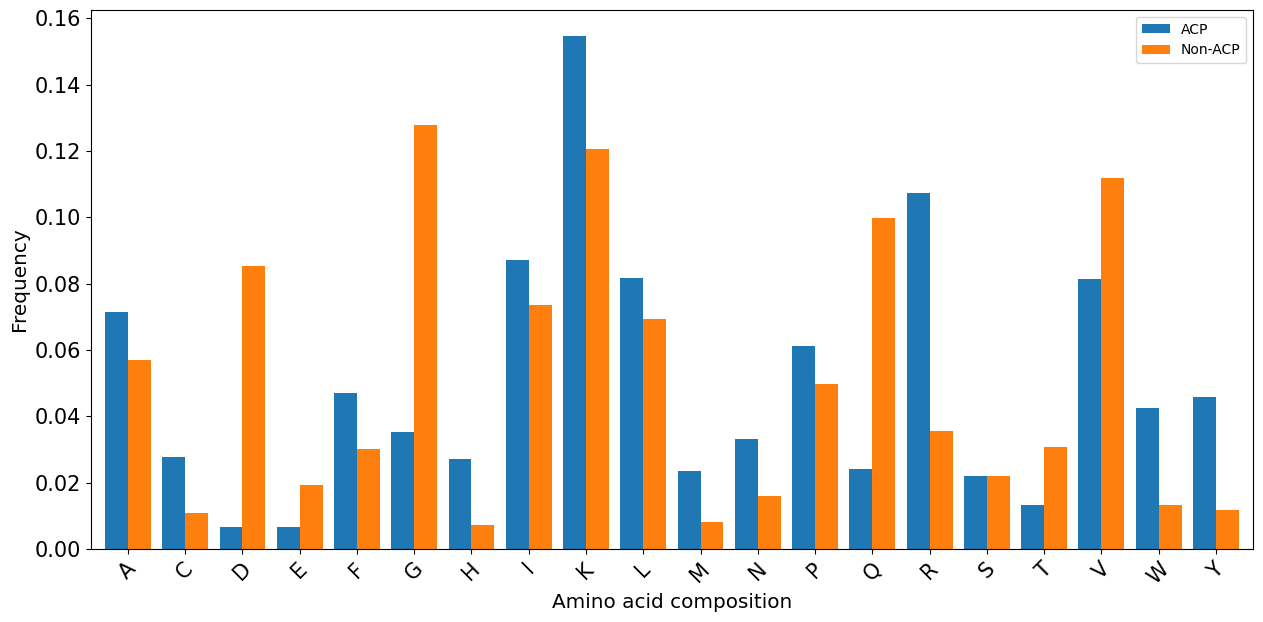

In [7]:
Seq_ACP = read_fasta('ACP_TRAIN.fasta')
Seq_Non_ACP = read_fasta('nonacp_TRAIN.fasta')
plot_aac(Seq_ACP,Seq_Non_ACP)

In [9]:
acpn5,acpc5 = seqN5C5(Seq_ACP)
nonacpn5,nonacpc5 = seqN5C5(Seq_Non_ACP)

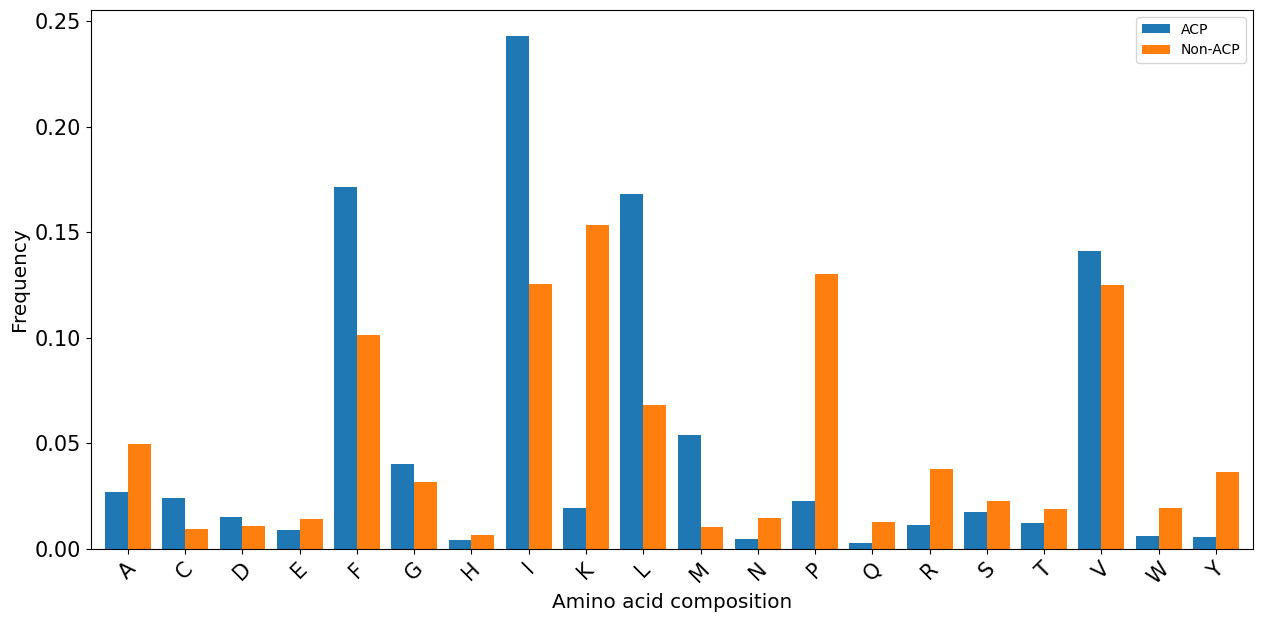

In [10]:
plot_N5C5(acpn5,nonacpn5)

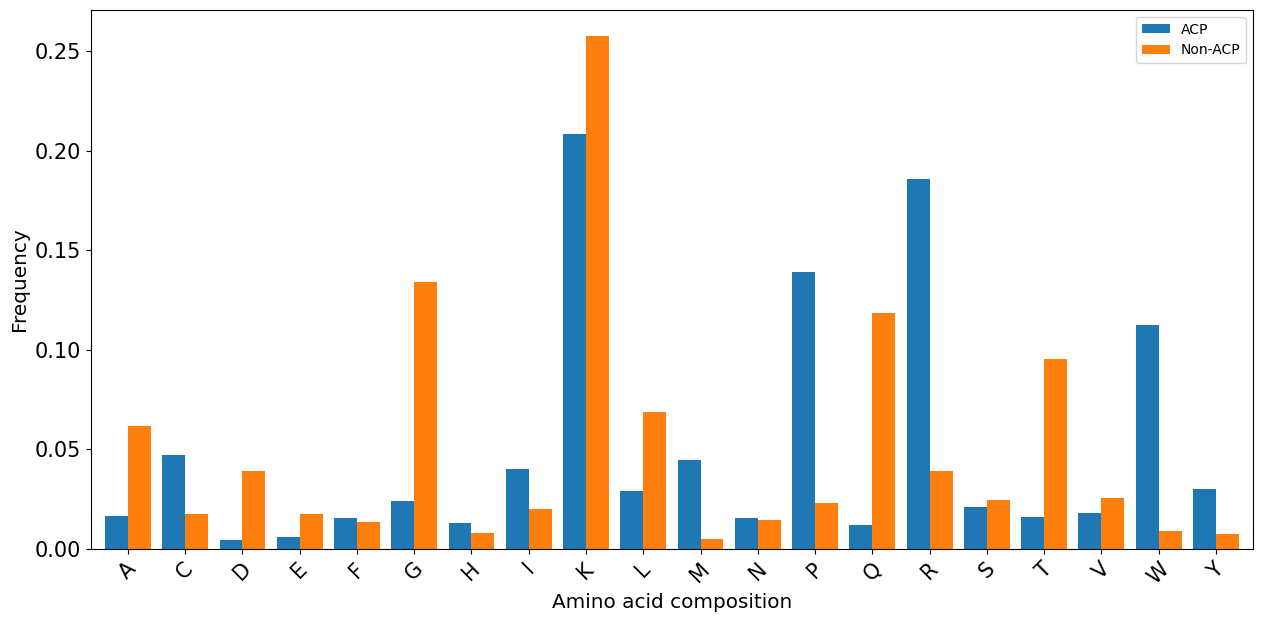

In [11]:
plot_N5C5(acpc5,nonacpc5)